In [1]:
# IMPORTIAMO TUTTE LE LIBRERIE NECESSARIE PER IL PROGETTO #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report
wr.filterwarnings('ignore')

In [2]:
# LEGGIAMO IL FILE CSV
df = pd.read_csv(r'C:\Users\Emanuele\Desktop\breast_cancer_data.csv',) 
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [3]:
df.shape
#verifichiamo quante righe e colonne

(569, 33)

In [4]:
df.info()
#verifichiamo i loro dtype

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
df.describe()
# visualizziamo dei dati statistici

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [6]:
df.isnull().sum()
#verifichiamo quanti dati null sono presenti

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
df.nunique()

id                         569
diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
Unnamed:

In [8]:
#quanti tumori sono benigni(B)) e quanti maligni(M) ?

tipo_tumore = df['diagnosis'].value_counts()
print(tipo_tumore)

diagnosis
B    357
M    212
Name: count, dtype: int64


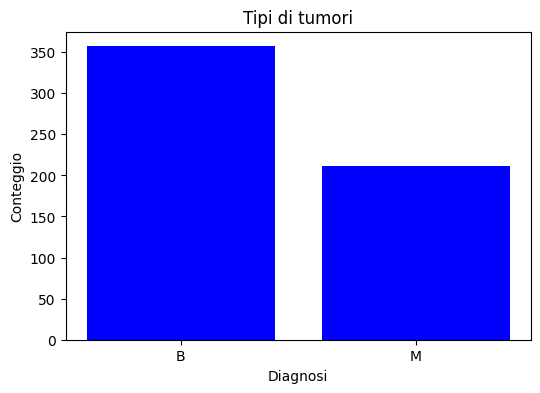

In [9]:
diagnosis_counts = df['diagnosis'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(diagnosis_counts.index, diagnosis_counts, color='blue')
plt.title('Tipi di tumori')
plt.xlabel('Diagnosi')
plt.ylabel('Conteggio')
plt.show()

# quanti tumori sono benigni(B) e quanti maligni(M)

In [10]:
#rendiamo la colonna B & M in 0 e 1
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [11]:
cols_list = df[['radius_se', 'texture_se', 'texture_worst', 'radius_mean', 'fractal_dimension_worst']]

# FACCIAMO LA LISTA DELLE NOSTRE VARIABILI PIù INTERESSANTI

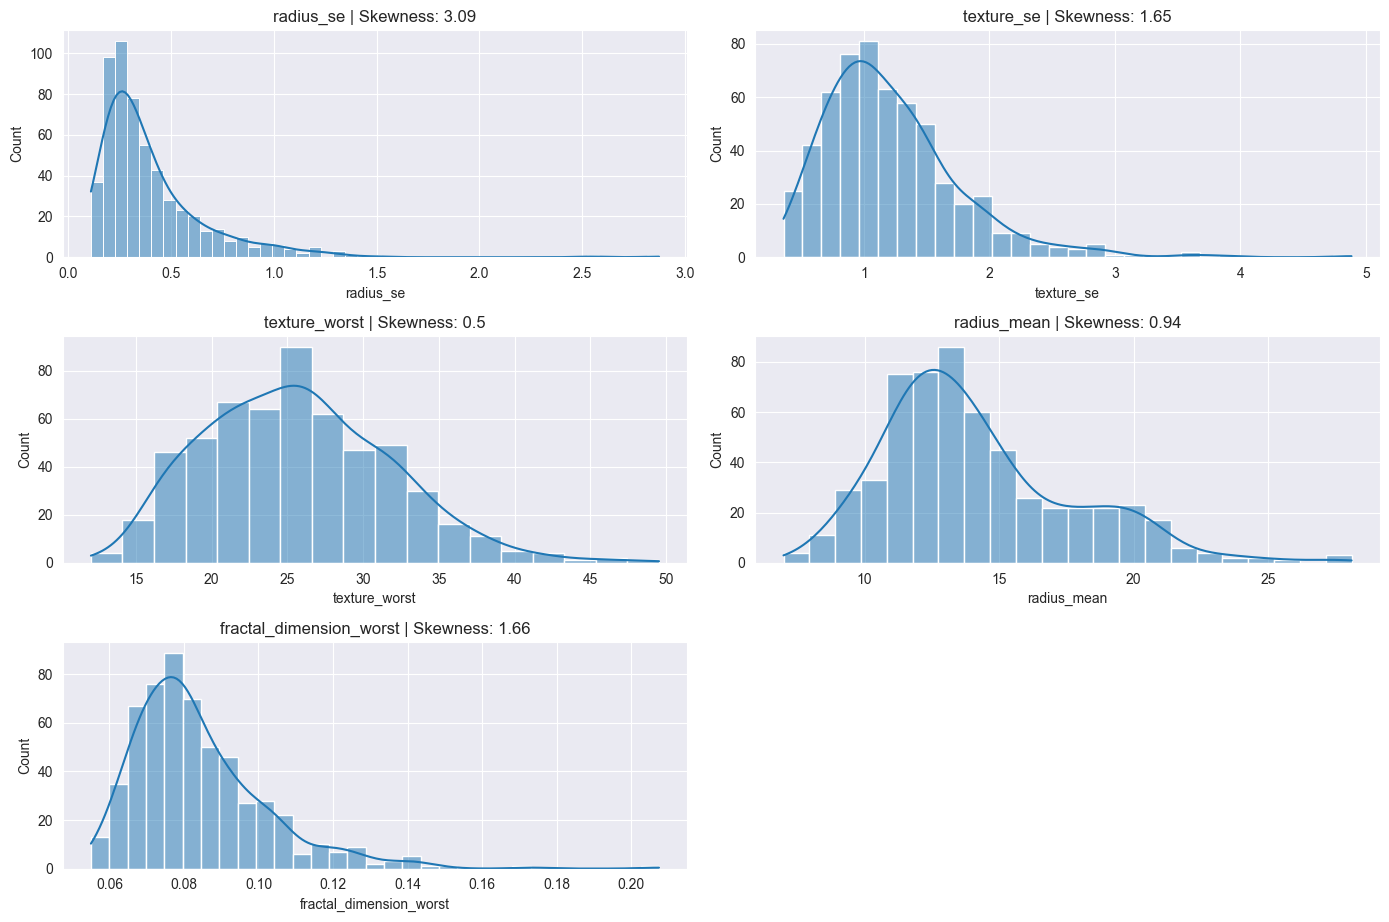

In [12]:
sns.set_style("darkgrid")

numerical_columns = cols_list.select_dtypes(include=["int64", "float64",]).columns.drop('id', errors='ignore')

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
  plt.subplot(len(numerical_columns), 2, idx)
  sns.histplot(df[feature], kde=True)
  plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

#FACCIAMO DATA FRAME SULLE COLONNE INTERESSATE

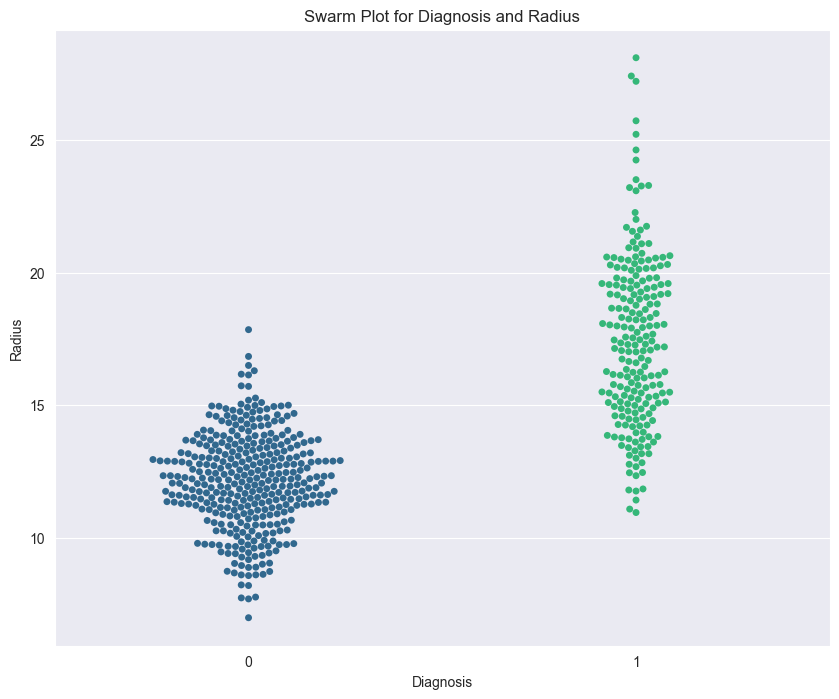

In [13]:
plt.figure(figsize=(10, 8))

sns.swarmplot(x="diagnosis", y="radius_mean", data=df, palette='viridis')

plt.title('Swarm Plot for Diagnosis and Radius')
plt.xlabel('Diagnosis')
plt.ylabel('Radius')
plt.show()

<Figure size 1000x600 with 0 Axes>

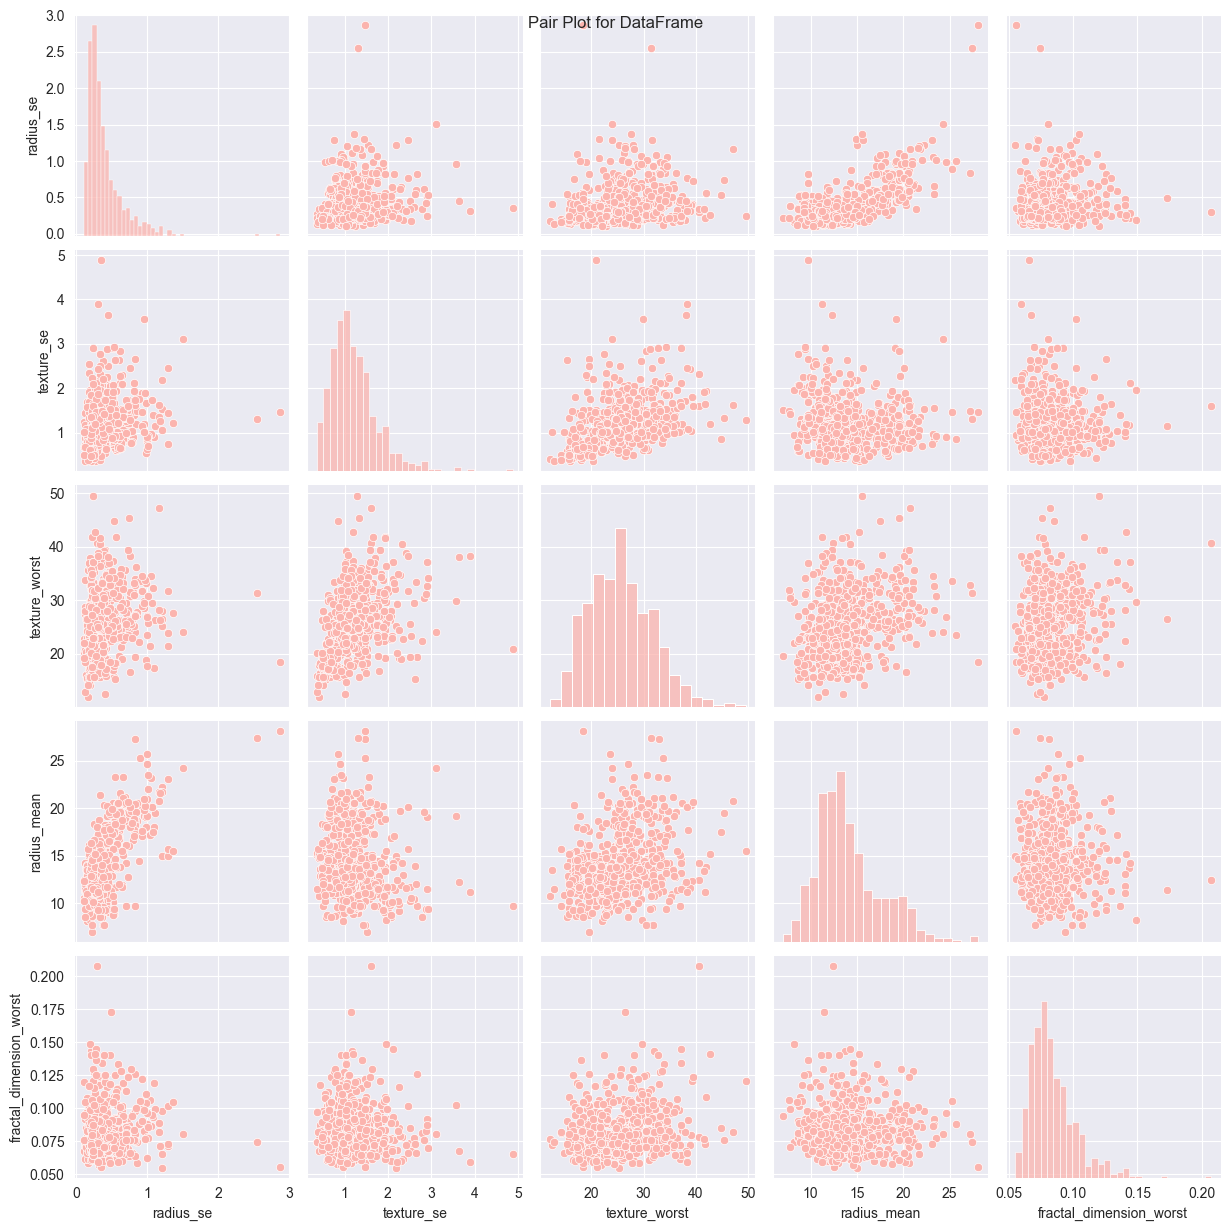

In [14]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(cols_list)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

# Pair plot delle colonne interessate

<Axes: xlabel='diagnosis', ylabel='radius_mean'>

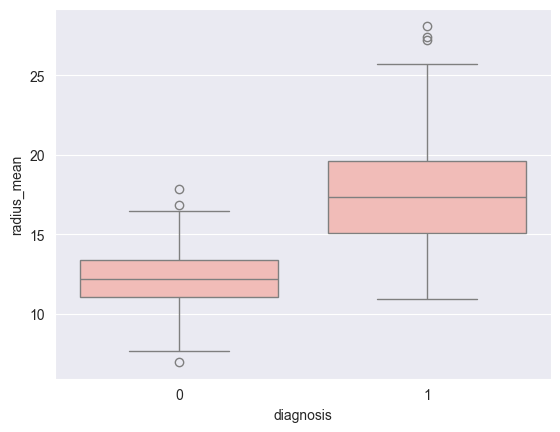

In [15]:
sns.boxplot(x='diagnosis', y='radius_mean', data=df)

# boxplot di radius e diagnosi

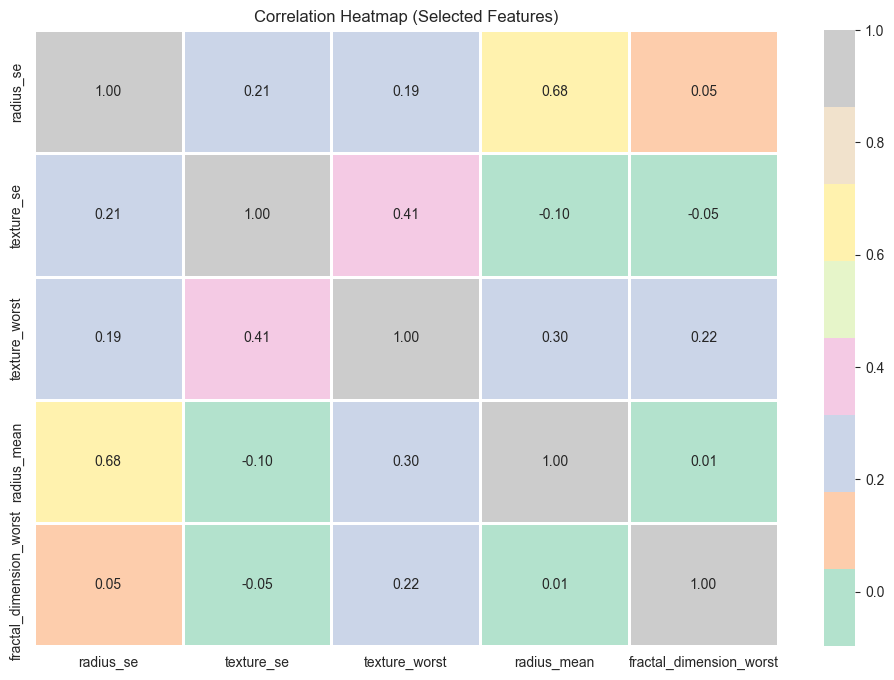

In [25]:
plt.figure(figsize=(12, 8))

sns.heatmap(df[cols_list].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='Pastel2', 
            linewidths=2)

plt.title('Correlation Heatmap (Selected Features)')
plt.show()

In [17]:
# stabiliamo le nostre variabili sulla asse X che trovi alla prima riga e la diagnosi nell'asse Y

cols_list = ['radius_se', 'texture_se', 'texture_worst', 'radius_mean', 'fractal_dimension_worst']

x = df[cols_list]
y = df.diagnosis

In [18]:
x_train , x_test , y_train , y_test = train_test_split(x, y , test_size= 0.25 , random_state= 42)

In [19]:
#facciamo le predict
logreg = LogisticRegression(random_state=42)

logreg.fit(x_train , y_train)

#facciamo le probabilità
y_pred = logreg.predict(x_test)
y_prob = logreg.predict_proba(x_test)

print(y_pred)
print('||||||||||||||||||||||||||||||||||||||||||')
print('Probabilità B o M\n' , y_prob*100)

[0 1 1 0 0 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 1 0 1 0]
||||||||||||||||||||||||||||||||||||||||||
Probabilità B o M
 [[9.12610526e+01 8.73894737e+00]
 [4.34642085e-01 9.95653579e+01]
 [2.10156800e+01 7.89843200e+01]
 [9.86101827e+01 1.38981733e+00]
 [9.98003592e+01 1.99640847e-01]
 [8.48282182e-03 9.99915172e+01]
 [1.67869333e-02 9.99832131e+01]
 [1.84536897e+01 8.15463103e+01]
 [9.09044877e+01 9.09551227e+00]
 [8.72834346e+01 1.27165654e+01]
 [4.57280541e+01 5.42719459e+01]
 [1.25687472e+01 8.74312528e+01]
 [6.19520354e+01 3.80479646e+01]
 [2.75727742e+01 7.24272258e+01]
 [9.82807335e+01 1.71926645e+00]
 [3.81965902e+00 9.61803410e+01]
 [9.11455635e+01 8.85443654e+00]
 [9.99153153e+01 8.46847136e-02]
 [9.99952530e+01 4.74696222e-03]
 [2.66462360e-01 9.9

In [20]:
#visualizziamo l'accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9370629370629371


Text(0.5, 23.52222222222222, 'Predicted diagnosis')

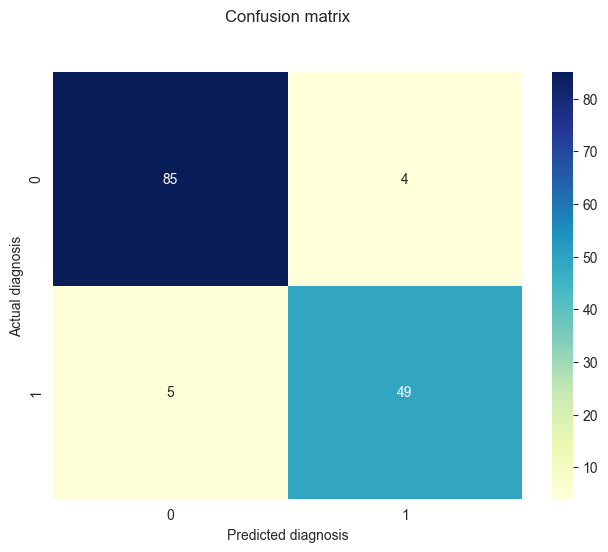

In [21]:
# IMPORTIAMO LA CLASS METRICS

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

class_names=[0,1] # <------- NOMI DELLE CLASSI
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# creiamo  heatmap per mostrare il margine di errore del modello

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual diagnosis')
plt.xlabel('Predicted diagnosis')

In [22]:
target_names = ['Diagnosis B', 'Diagnosis M']
print(classification_report(y_test, y_pred, target_names=target_names))
# Il "support" indica quanti casi reali c'erano per ogni categoria:

              precision    recall  f1-score   support

 Diagnosis B       0.94      0.96      0.95        89
 Diagnosis M       0.92      0.91      0.92        54

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



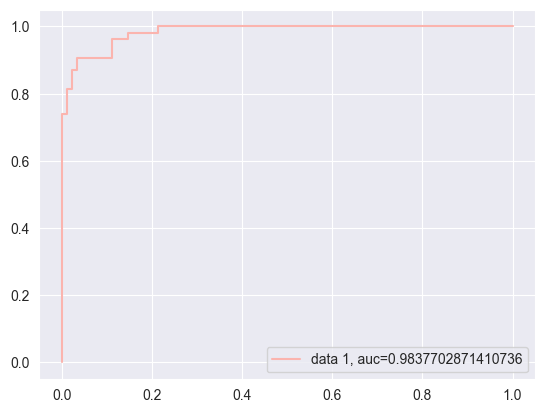

In [23]:
y_pred_proba = logreg.predict_proba(x_test)[::,1]
y_test_numeric = y_test.astype(int)
fpr, tpr, _ = metrics.roc_curve(y_test_numeric,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()